_Date: 27th June 2026  
Authors: Soledad, Benay, and Andre_

# Automated Customer Reviews (NLP)

## <span style="background-color:#D8BFD8; color:black; padding:8px; border-radius:4px;">Section 0: Setup & Data Loading</span>

In this section the following points will be covered:  
<span style="color: purple">**0.1 Imports and load raw datasets**  </span>  
<span style="color: purple">**0.2 Initial inspection**</span>

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;">0.1 Imports and load raw datasets</span>
The following notebook uses the following for its construction:
- Standard data handling (pandas, numpy)
- NLP (nltk/transformers)
- Modeling (scikit-learn, Hugging Face) libraries.

The primary dataset is the **Datafiniti Amazon Product Reviews dataset**,  supplemented with the larger **McAuley Amazon Reviews** dataset for more volume.

In the following sections we preprocess this data, then build the three required components: a sentiment classifier, a category clustering model, and a generative summarizer.

In [1]:
##_________1. Download first DataSet: Datafiniti Amazon Product Reviews dataset____________

import kagglehub
import os

path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")
print("Files available:", os.listdir(path))

import pandas as pd

# See what files are available
files = os.listdir(path)
print("Files available:", files)

# Read the CSV file(s) into a dataframe
csv_files = [f for f in files if f.endswith('.csv')]

if len(csv_files) == 1:
    df_primary = pd.read_csv(os.path.join(path, csv_files[0])) # Short Dataset with many columns
else:
    # If multiple CSVs, combine them all
    df_primary = pd.concat([pd.read_csv(os.path.join(path, f)) for f in csv_files], ignore_index=True)

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Files available: ['Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', '1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']
Files available: ['Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', '1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']


/tmp/ipykernel_1909/1496382784.py:22: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_primary = pd.concat([pd.read_csv(os.path.join(path, f)) for f in csv_files], ignore_index=True)


In [2]:
##2. Download second DataSet: McAuley Amazon Reviews_____________________________

# Install dependencies (run once; restart kernel if prompted)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "datasets<3.0.0", "--upgrade"])

from datasets import load_dataset
import pandas as pd
import os
import time
import gc
import glob

# --- Settings ---
OUTPUT_DIR = "amazon_reviews_2023_sampled"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SAMPLE = 100_000      # reviews to sample per category
SEED = 42
BUFFER_SIZE = 50_000    # shuffle buffer size for streaming sample

CATEGORIES = [
    "All_Beauty", "Amazon_Fashion", "Appliances", "Arts_Crafts_and_Sewing",
    "Automotive", "Baby_Products", "Beauty_and_Personal_Care", "Books",
    "CDs_and_Vinyl", "Cell_Phones_and_Accessories", "Clothing_Shoes_and_Jewelry",
    "Digital_Music", "Electronics", "Gift_Cards", "Grocery_and_Gourmet_Food",
    "Handmade_Products", "Health_and_Household", "Health_and_Personal_Care",
    "Home_and_Kitchen", "Industrial_and_Scientific", "Kindle_Store",
    "Magazine_Subscriptions", "Movies_and_TV", "Musical_Instruments",
    "Office_Products", "Patio_Lawn_and_Garden", "Pet_Supplies",
    "Software", "Sports_and_Outdoors", "Subscription_Boxes",
    "Tools_and_Home_Improvement", "Toys_and_Games", "Video_Games",
    "Unknown",
]


# --- Fetch the data ---
review_log = []
for category in CATEGORIES:
    out_path = os.path.join(OUTPUT_DIR, f"review_{category}_sample.parquet")
    if os.path.exists(out_path):
        print(f"[skip] {category} reviews already sampled")
        continue
    t0 = time.time()
    try:
        print(f"[stream] raw_review_{category} ...")
        ds = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            f"raw_review_{category}",
            trust_remote_code=True,
            split="full",
            streaming=True,
        )
        shuffled = ds.shuffle(seed=SEED, buffer_size=BUFFER_SIZE)
        rows = list(shuffled.take(N_SAMPLE))
        df = pd.DataFrame(rows)
        df["category"] = category
        df.to_parquet(out_path, index=False)
        print(f"  -> {len(df):,} rows saved ({time.time()-t0:.1f}s)")
        review_log.append({"category": category, "rows": len(df), "status": "ok"})
        del ds, shuffled, rows, df
        gc.collect()
    except Exception as e:
        print(f"  !! FAILED: {e}")
        review_log.append({"category": category, "rows": None, "status": str(e)})



# --- Ready to use dataframe ---
review_files = glob.glob(os.path.join(OUTPUT_DIR, "review_*_sample.parquet"))

df_secondary = pd.concat([pd.read_parquet(f) for f in review_files], ignore_index=True)

df_secondary.to_parquet(os.path.join(OUTPUT_DIR, "ALL_reviews_sampled.parquet"), index=False)





[stream] raw_review_All_Beauty ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  -> 100,000 rows saved (27.3s)
[stream] raw_review_Amazon_Fashion ...
  -> 100,000 rows saved (19.9s)
[stream] raw_review_Appliances ...
  -> 100,000 rows saved (23.3s)
[stream] raw_review_Arts_Crafts_and_Sewing ...
  -> 100,000 rows saved (22.2s)
[stream] raw_review_Automotive ...
  -> 100,000 rows saved (19.0s)
[stream] raw_review_Baby_Products ...
  -> 100,000 rows saved (22.2s)
[stream] raw_review_Beauty_and_Personal_Care ...
  -> 100,000 rows saved (25.1s)
[stream] raw_review_Books ...
  -> 100,000 rows saved (35.8s)
[stream] raw_review_CDs_and_Vinyl ...
  -> 100,000 rows saved (24.4s)
[stream] raw_review_Cell_Phones_and_Accessories ...
  -> 100,000 rows saved (20.9s)
[stream] raw_review_Clothing_Shoes_and_Jewelry ...
  -> 100,000 rows saved (23.7s)
[stream] raw_review_Digital_Music ...
  -> 100,000 rows saved (21.7s)
[stream] raw_review_Electronics ...
  -> 100,000 rows saved (25.7s)
[stream] raw_review_Gift_Cards ...
  -> 100,000 rows saved (15.3s)
[stream] raw_review_Grocery_a

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 0.2 Initial Inspection
</span>



We inspect the dataset to confirm which columns map to review text(reviews.text), rating (reviews.rating), and product/category (categories, name), since this determines how Sections 3 and 5 are built.

In [3]:
df_primary.head(3)

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,reviews.didPurchase,reviews.userCity,reviews.userProvince
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,0.0,3.0,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...,NaN,NaN,NaN
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,0.0,5.0,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...,NaN,NaN,NaN
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,0.0,4.0,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...,NaN,NaN,NaN


In [4]:
df_secondary.head(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
0,5.0,Buy THIS album...or get the OTHER one (if you ...,"You either love Quo, or hate 'em. Speaking per...",[],B00000743E,B00000743E,AH7UKE3JVRDLDME7ZEDCPVF7QS5Q,1210646073000,1,False,CDs_and_Vinyl
1,5.0,Ummm Hummm,"This is a very good compilation of songs, some...",[],B000001F7N,B000001F7N,AGKOVIESAAQDKF7FRVQDGVTUCECA,1440717394000,0,True,CDs_and_Vinyl
2,5.0,Gifting Jesus Style,Bought this for a friend. She was absolutely t...,[],B00008L412,B00008L412,AGJRW2IYOW5Z3STDPJZVHIUHIULA,1457496818000,0,True,CDs_and_Vinyl


df_primary — Datafiniti Amazon Product Reviews (67,992 rows × 27 columns):
- id — unique product identifier (Datafiniti's internal ID).
- dateAdded — date the product record was first added to Datafiniti's catalog.
- dateUpdated — date the product record was last updated.
- name — product name.
- asins — Amazon Standard Identification Number(s) for the product.
- brand — product brand.
- manufacturer — product manufacturer.
- manufacturerNumber — manufacturer's model/part number.
- categories — comma-separated full category tags.
- primaryCategories — simplified/top-level category.
- keys — a normalized key combining product attributes, used for matching or deduping.
- imageURLs — URL(s) to product images.
- sourceURLs — URL(s) where the product listing was scraped from.
- reviews.date — date the review was written.
- reviews.dateAdded — date the review was added to Datafiniti's dataset.
- reviews.dateSeen — date(s) Datafiniti's scraper observed the review.
- reviews.doRecommend — boolean, whether the reviewer would recommend the product.
- reviews.id — review ID.
- reviews.numHelpful — count of "helpful" votes the review received.
- reviews.rating — star rating.
- reviews.sourceURLs — URL(s) the review was scraped from.
- reviews.text — the actual review body text.
- reviews.title — short review headline.
- reviews.username — reviewer's display name.
- reviews.didPurchase — boolean, whether the review confirms a verified purchase.
- reviews.userCity — reviewer's city.
- reviews.userProvince — reviewer's state/province.



df_secondary — McAuley Amazon Reviews 2023 (3,287,713 rows × 11 columns):
- rating — star rating.
- title — short review headline.
- text — the actual review body text.
- images — list of image URLs attached to the review.
- asin — Amazon product ID for the specific product variant reviewed.
- parent_asin — Amazon product ID for the "parent" product.
- user_id — anonymized and hashed reviewer ID.
- timestamp — datetime the review was posted.
- helpful_vote — count of helpful votes the review received.
- verified_purchase — boolean, whether Amazon verified the reviewer actually purchased the product.
- category - product cateogry based on the dataset name.

__________________________________________________________

## <span style="background-color:#D8BFD8; color:black; padding:8px; border-radius:4px;">Section 1: Exploratory Data Analysis</span>

In this section the following points will be covered:  
<span style="color: purple">**1.1 First Dataset overview & data quality**  </span>   
<span style="color: purple">**1.2 Second Dataset overview & data quality**  </span>   
<span style="color: purple">**1.3 Manual Inspection**  </span>   

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 1.1 First Dataset overview & data quality
</span>


We check dtypes, missing values, duplicate reviews and basic stats across the First dataset.

In [5]:
print(df_primary.columns)
df_primary.info()

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'reviews.didPurchase', 'reviews.userCity', 'reviews.userProvince'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67992 entries, 0 to 67991
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    67992 non-null  object 
 1   dateAdded             33332 non-null  object 
 2   dateUpdated           33332 non-null  object 
 3   name                  61232 non-null  object 
 4   asins                 67990 non-null  object 
 5   brand        

In [6]:
df_primary.describe(include='all')

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,reviews.didPurchase,reviews.userCity,reviews.userProvince
count,67992,33332,33332,61232,67990,67992,67992,33332,33332,67992,...,55246.000000,67959.000000,67992,67991,67973,67979,33332,10,0.0,0.0
unique,92,58,69,125,94,8,111,10,88,116,...,NaN,NaN,22122,46909,25788,37570,89,2,NaN,NaN
top,AVphgVaX1cnluZ0-DR74,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",B018Y229OU,Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",Electronics,https://images-na.ssl-images-amazon.com/images...,firetablet7displaywifi8gbincludesspecialoffers...,...,NaN,NaN,https://www.amazon.com/product-reviews/B00QWO9...,good,Five Stars,ByAmazon Customer,"https://www.barcodable.com/upc/841710106442,ht...",True,NaN,NaN
freq,10966,8343,8343,10966,10966,49854,10966,17271,8343,10966,...,NaN,NaN,12071,61,4100,889,8343,9,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.572041,4.556071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.587020,0.825126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Full-row duplicates
duplicates = df_primary[df_primary.duplicated()]
print("Duplicated Rows (full): " + str(len(duplicates)))

# Duplicate review text
text_duplicates = df_primary[df_primary.duplicated(subset=['reviews.text'])]
print("Duplicated Rows (text only): " + str(len(text_duplicates)))

Duplicated Rows (full): 95
Duplicated Rows (text only): 21082


Comment: ~21,082 of 67,992 primary reviews (≈31%) share identical `reviews.text` with another row, versus only 95 full-row duplicates. The gap between these two numbers means the same review text appears attached to *different* metadata (different dates, usernames, etc.) far more often than it appears as an exact repeated row.

In [8]:
# Display the distribution
df_primary['reviews.rating'].value_counts().sort_index()

,count
reviews.rating,
1.0,1438
2.0,1072
3.0,2902
4.0,15397
5.0,47150


Comment: Primary ratings are heavily skewed positive, which is about 92% of reviews are 4 or 5 stars, and only 1,438 (2.1%) are 1-star. This imbalance is the motivation for the class-balancing step in Section 2.2.

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 1.2 Second Dataset overview & data quality
</span>


We check dtypes, missing values, duplicate reviews and basic stats across the Second Dataset.

In [9]:
print(df_secondary.columns)
df_secondary.info()

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'category'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287713 entries, 0 to 3287712
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   rating             float64
 1   title              object 
 2   text               object 
 3   images             object 
 4   asin               object 
 5   parent_asin        object 
 6   user_id            object 
 7   timestamp          int64  
 8   helpful_vote       int64  
 9   verified_purchase  bool   
 10  category           object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 254.0+ MB


In [10]:
df_secondary.describe()

,rating,timestamp,helpful_vote
count,3.287713e+06,3.287713e+06,3.287713e+06
mean,4.304050e+00,1.536345e+12,1.372482e+00
std,1.201951e+00,1.011187e+11,1.378909e+01
min,1.000000e+00,8.715715e+11,-3.000000e+00
25%,4.000000e+00,1.473381e+12,0.000000e+00
50%,5.000000e+00,1.555887e+12,0.000000e+00
75%,5.000000e+00,1.613785e+12,1.000000e+00
max,5.000000e+00,1.693601e+12,7.100000e+03


In [11]:
# Exclude 'images' column because it contains URL lists that differ between
# identical reviews, so including it would cause real duplicates to be missed
columns_to_check = [col for col in df_secondary.columns if col != 'images']

# Full-row duplicates, excluding the 'images' column
duplicates = df_secondary[df_secondary.duplicated(subset=columns_to_check)]
print("Duplicated Rows (full): " + str(len(duplicates)))

# Duplicate review text
text_duplicates = df_secondary[df_secondary.duplicated(subset=['text'])]
print("Duplicated Rows (text only): " + str(len(text_duplicates)))

Duplicated Rows (full): 5085
Duplicated Rows (text only): 304810


Comment: The `images` column is deliberately excluded from the full-row duplicate check since list-valued columns rarely match by accident and can hide genuine duplicates. The result (5,085 full-row duplicates vs. 304,810 text-only duplicates) shows the same pattern as the primary dataset, identical review text reused across rows with different metadata is far more common than literal duplicate rows.

In [12]:
# Display the distribution
df_secondary['rating'].value_counts().sort_index()

,count
rating,
1.0,228837
2.0,136542
3.0,244363
4.0,474383
5.0,2203588


Comment: Secondary ratings are also skewed positive (67% are 5-star) but noticeably less extreme than the primary dataset, and with a healthier share of 1-star and 2-star reviews (228,837 and 136,542 respectively). This is exactly why `df_secondary` is later used as the donor pool to top up underrepresented rating classes in Section 2.2 because it simply has more low-rating reviews available to draw from.

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 1.3 Manual Inspection
</span>



Inspection of a sample of real reviews, sanity-check category labels, build intuition about data quality before modeling anything.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

reviews_per_product_primary = df_primary.groupby("id").size().sort_values(ascending=False)

# A. Reviews-per-product — Primary dataset
print("=== PRIMARY DATASET ===")
print(f"Total reviews:        {len(df_primary):,}")
print(f"Unique products:      {df_primary['id'].nunique():,}")
print(f"Reviews per product -> min: {reviews_per_product_primary.min()}, "
      f"median: {reviews_per_product_primary.median():.0f}, "
      f"max: {reviews_per_product_primary.max()}")
print()
print("Top 5 most-reviewed products:")
print(reviews_per_product_primary.head(5))
print()
print("Bottom 5 least-reviewed products:")
print(reviews_per_product_primary.tail(5))


=== PRIMARY DATASET ===
Total reviews:        67,992
Unique products:      92
Reviews per product -> min: 1, median: 19, max: 10966

Top 5 most-reviewed products:
id
AVphgVaX1cnluZ0-DR74    10966
AVpgNzjwLJeJML43Kpxn     8343
AVpfl8cLLJeJML43AE3S     6621
AV1YE_muvKc47QAVgpwE     5056
AVpe7xlELJeJML43ypLz     3728
dtype: int64

Bottom 5 least-reviewed products:
id
AV2ElNnuvKc47QAVouhY    1
AVqkEM34QMlgsOJE6e8q    1
AVpiZQ8r1cnluZ0-M3MN    1
AVzoFq6UvKc47QAVe9NB    1
AVzvV7FHglJLPUi8GzhD    1
dtype: int64


Comment: Confirms the long-tail pattern flagged in the Section 1 observations: the top-5 products in `df_primary` alone account for over 34,000 of the 67,992 total reviews (~50%), while the bottom products have only a single review. Any model trained on this data risks learning product-specific vocabulary rather than generalizable sentiment patterns, since a handful of products dominate the volume.

In [14]:
# B. Reviews-per-product — Secondary dataset
# 'asin' is the unique product identifier in df_secondary

reviews_per_product_secondary = df_secondary.groupby("asin").size().sort_values(ascending=False)

print("\n=== SECONDARY DATASET ===")
print(f"Total reviews:        {len(df_secondary):,}")
print(f"Unique products:      {df_secondary['asin'].nunique():,}")
print(f"Reviews per product -> min: {reviews_per_product_secondary.min()}, "
      f"median: {reviews_per_product_secondary.median():.0f}, "
      f"max: {reviews_per_product_secondary.max()}")
print()
print("Top 5 most-reviewed products:")
print(reviews_per_product_secondary.head(5))
print("Bottom 5 least-reviewed products:")
print(reviews_per_product_secondary.tail(5))


=== SECONDARY DATASET ===
Total reviews:        3,287,713
Unique products:      1,833,566
Reviews per product -> min: 1, median: 1, max: 22910

Top 5 most-reviewed products:
asin
B00IX1I3G6    22910
B086KKT3RX     4095
B003LPTAYI     4055
B08C7HDF1F     3588
B01K8RMDO0     2913
dtype: int64
Bottom 5 least-reviewed products:
asin
B001B0F3NW    1
B01K4HWU4C    1
B01K4HWSHG    1
B01K4HW8CG    1
B01K4IK9LC    1
dtype: int64


Comment: The secondary dataset's product distribution is the mirror opposite of the primary one as most products (asin values) have just 1–2 reviews, with a long tail of popular items topping out at ~22,910 reviews. This breadth (1,833,566 unique products) is the main reason this dataset is used to balance classes and add volume, rather than depth on any single product.

In [15]:
# C. Missing values — both datasets side by side
missing_primary = (
    df_primary.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: (d["missing_count"] / len(df_primary) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

missing_secondary = (
    df_secondary.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: (d["missing_count"] / len(df_secondary) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

print("=== MISSING VALUES — Primary ===")
print(missing_primary if len(missing_primary) else "No missing values.")
print("\n=== MISSING VALUES — Secondary ===")
print(missing_secondary if len(missing_secondary) else "No missing values.")



=== MISSING VALUES — Primary ===
                      missing_count  missing_pct
reviews.userCity              67992       100.00
reviews.userProvince          67992       100.00
reviews.didPurchase           67982        99.99
reviews.id                    67921        99.90
reviews.dateAdded             42901        63.10
manufacturerNumber            34660        50.98
dateUpdated                   34660        50.98
dateAdded                     34660        50.98
sourceURLs                    34660        50.98
imageURLs                     34660        50.98
primaryCategories             34660        50.98
reviews.doRecommend           12840        18.88
reviews.numHelpful            12746        18.75
name                           6760         9.94
reviews.date                     39         0.06
reviews.rating                   33         0.05
reviews.title                    19         0.03
reviews.username                 13         0.02
asins                             2 

Comment: `df_primary` has substantial missingness concentrated in catalog/scraper metadata (`reviews.userCity`, `reviews.userProvince`, `reviews.didPurchase`, `reviews.id` are essentially empty), but the core modeling fields (`reviews.text`, `reviews.rating`, `reviews.title`) are almost fully populated (<0.1% missing each). `df_secondary` has zero missing values in any column — consistent with it being a cleaner, more recent, programmatically-curated dataset.

In [16]:
# D. Review text length distribution (sanity-check for junk/empty reviews)
df_primary["review_len_words"] = df_primary["reviews.text"].fillna("").apply(lambda t: len(str(t).split()))
df_secondary["review_len_words"] = df_secondary["text"].fillna("").apply(lambda t: len(str(t).split()))

print("=== REVIEW LENGTH (words) — Primary ===")
print(df_primary["review_len_words"].describe())
print(f"Reviews under 3 words: {(df_primary['review_len_words'] < 3).sum():,} "
      f"({(df_primary['review_len_words'] < 3).mean()*100:.2f}%)")

print("\n=== REVIEW LENGTH (words) — Secondary ===")
print(df_secondary["review_len_words"].describe())
print(f"Reviews under 3 words: {(df_secondary['review_len_words'] < 3).sum():,} "
      f"({(df_secondary['review_len_words'] < 3).mean()*100:.2f}%)")

=== REVIEW LENGTH (words) — Primary ===
count    67992.000000
mean        28.586025
std         36.629444
min          0.000000
25%         12.000000
50%         19.000000
75%         34.000000
max       1858.000000
Name: review_len_words, dtype: float64
Reviews under 3 words: 2,141 (3.15%)

=== REVIEW LENGTH (words) — Secondary ===
count    3.287713e+06
mean     5.208831e+01
std      8.748131e+01
min      0.000000e+00
25%      9.000000e+00
50%      2.500000e+01
75%      5.900000e+01
max      6.040000e+03
Name: review_len_words, dtype: float64
Reviews under 3 words: 238,002 (7.24%)


Comment: Both datasets have a similar median review length (19 words). The secondary dataset has a heavier short review tail (7.24% under 3 words vs. 3.15% for primary), which lines up with the higher full duplicate text rate seen earlier. Short reviews like "Great!" or "Love it" are exactly the kind of text likely to repeat across unrelated products.

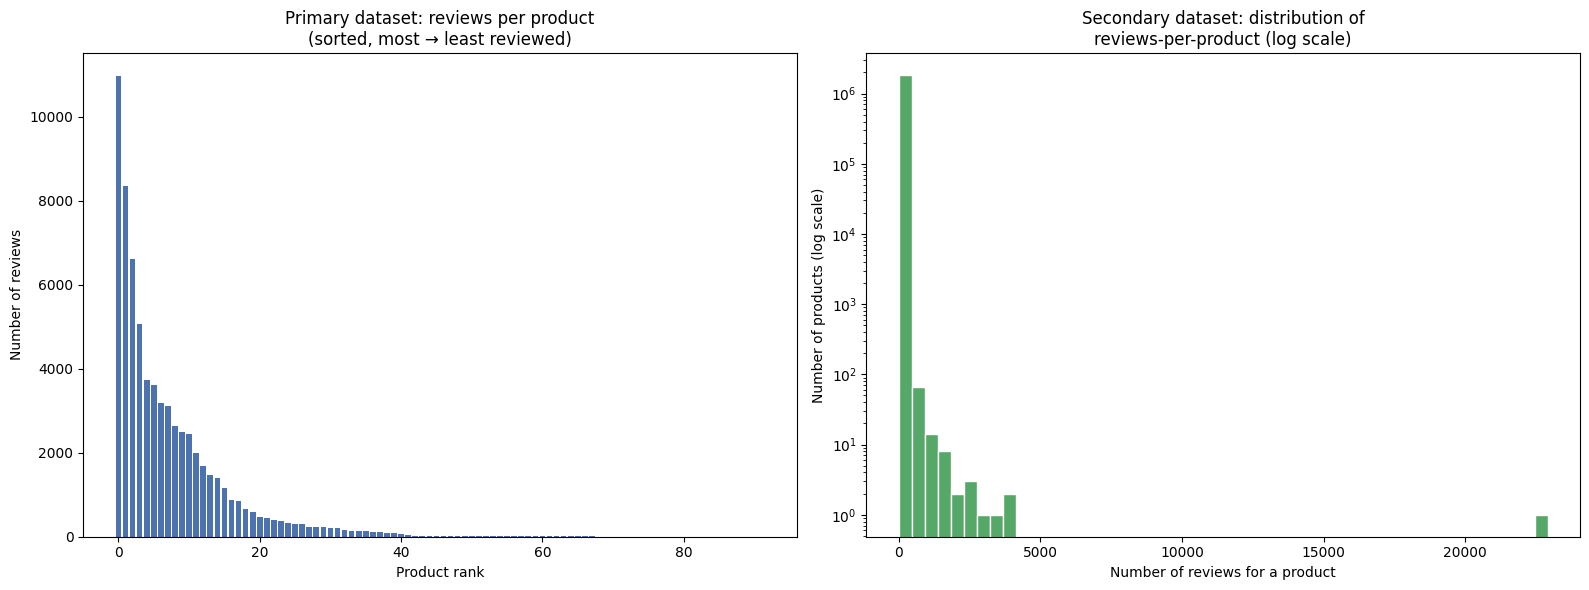

In [17]:
# E. Visual 1 — Reviews per product (concentration / long-tail check)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(reviews_per_product_primary)), reviews_per_product_primary.values, color="#4C72B0")
axes[0].set_title("Primary dataset: reviews per product\n(sorted, most → least reviewed)")
axes[0].set_xlabel("Product rank")
axes[0].set_ylabel("Number of reviews")

axes[1].hist(reviews_per_product_secondary.values, bins=50, color="#55A868", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Secondary dataset: distribution of\nreviews-per-product (log scale)")
axes[1].set_xlabel("Number of reviews for a product")
axes[1].set_ylabel("Number of products (log scale)")

plt.tight_layout()
plt.show()

Comment — Visual 1: Confirms the primary dataset's bar chart drops off in a steep, almost step-like curve (a handful of products with thousands of reviews, the rest comparatively bare), while the secondary dataset's log-scale histogram piles up at the low end, which is the classic long-tail shape expected from a marketplace-wide review dump.

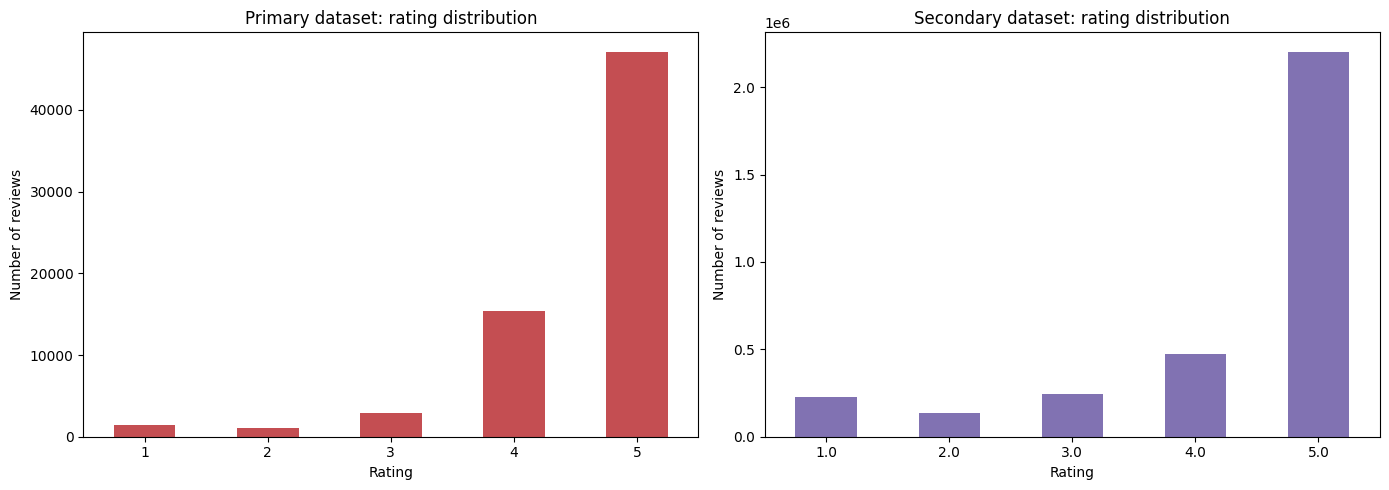

In [18]:
# F. Visual 2 — Rating distribution, both datasets side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_primary["reviews.rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#C44E52"
)
axes[0].set_title("Primary dataset: rating distribution")

labels = [tick.get_text() for tick in axes[0].get_xticklabels()]
new_labels = [label[:-2] for label in labels]
axes[0].set_xticklabels(new_labels, rotation=0)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of reviews")



df_secondary["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#8172B2"
)
axes[1].set_title("Secondary dataset: rating distribution")
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()


Comment — Visual 2: Side-by-side rating histograms display both datasets lean heavily toward 5-star reviews, but the secondary dataset has a comparatively larger low-rating bucket, reinforcing why it's the better donor pool for class balancing.

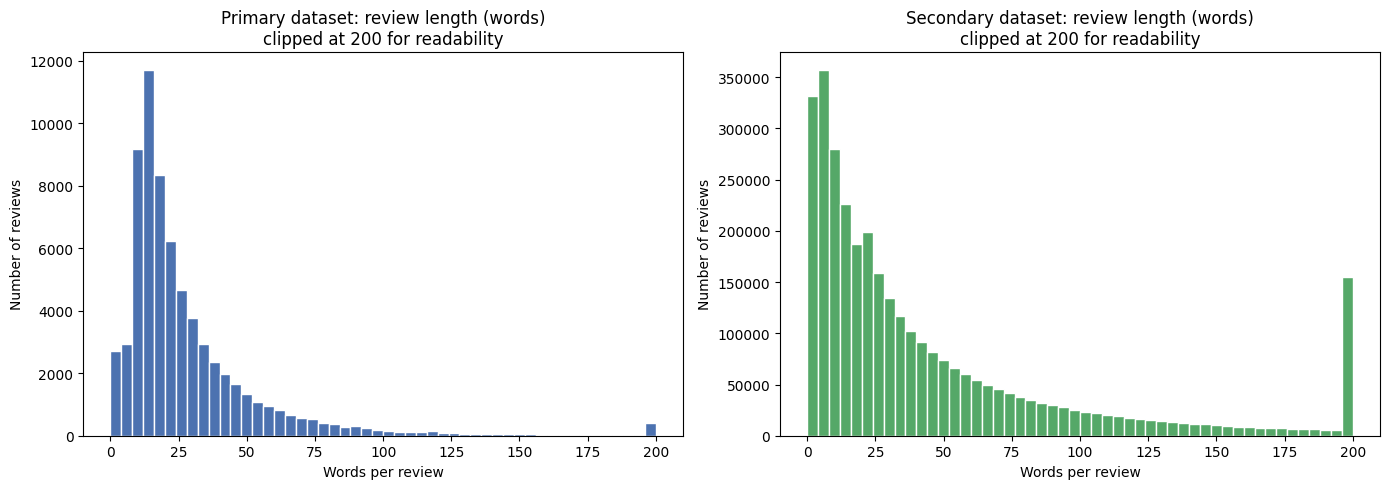

In [19]:
# G. Visual 3 — Review length distribution (helps spot junk/spam reviews)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_primary["review_len_words"].clip(upper=200), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Primary dataset: review length (words)\nclipped at 200 for readability")
axes[0].set_xlabel("Words per review")
axes[0].set_ylabel("Number of reviews")

axes[1].hist(df_secondary["review_len_words"].clip(upper=200), bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("Secondary dataset: review length (words)\nclipped at 200 for readability")
axes[1].set_xlabel("Words per review")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()


Comment — Visual 3: Both review-length histograms are right-skewed with a long tail of very long reviews (note the clip(upper=200) is purely for plotting readability. The bulk of reviews in both datasets sit comfortably above the 10-word threshold chosen in Section 2.1.

**Observations**

**1. The two datasets are very different in shape, not just size, and a small handful of products dominate the review volume**
- The primary dataset (Datafiniti) is the opposite: Total reviews are 67,992 for only 92 unique products. Additionnally, some products have ~11,000 reviews each, whereas others only a few. The dataset has several features related to metadata.
- The secondary (McAuley) dataset has 3,287,713 reviews across 1,833,566 products. The median reviews per product is 1 review. Also, almost no product catalog metadata is present.

 **2. Review length looks healthy overall, but there's a meaningful junk tail**
- Median review length is reasonable in both (19 words primary, 19 words secondary)
- The part worth flagging: 3.15% of primary reviews and 7.24% of secondary reviews are under 3 words.



__________________________

## <span style="background-color:#D8BFD8; color:black; padding:8px; border-radius:4px;">Section 2: Feature Engineering & Merging </span>




In this section the following points will be covered:  

<span style="color: purple">**2.1 Text cleaning** </span>  : define what cleaning is actually needed for transformer models (light — these models expect fairly natural text, so this is mostly de-duplication, language filtering, length filtering, not aggressive stemming/stopword removal).
<span style="color: purple"> **2.2 Class Balancing, Column standardization & Merging of Datasets**   </span>    
<span style="color: purple">**2.3 Sentiment label mapping** </span>  : map 1–2 stars → Negative, 3 → Neutral, 4–5 → Positive

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 2.1 Text Cleaning
</span>

### **What counts as "too short"?**
The EDA in Section 1 already told us that reviews under 3 words are junk (3.15% of primary, 7.24% of secondary). But for a transformer model, 3 words is still borderline useless (something like "great product thanks" gives almost no signal). A threshold of 10 words is more defensible for classification.

### **Language filtering?**
The primary dataset is English-only Amazon US products. The secondary (McAuley Beauty) is also predominantly English. Running a language detector on 230,000 rows is slow and usually catches only a tiny fraction. We skip it for now. If the classifier struggles on weird inputs later, we can come back.

In [20]:
##______________1. Column Standardization & Merging of Datasets__________________

# Step 1: Rename df_primary columns to match df_secondary naming convention
df_primary_renamed = df_primary.rename(columns={
    'asins':                'asin',
    'reviews.rating':       'rating',
    'reviews.title':        'title',
    'reviews.text':         'text',
    'reviews.didPurchase':  'verified_purchase',
    'reviews.numHelpful':   'helpful_vote',
    'reviews.username':     'user_id',
    'reviews.date':         'timestamp',
})

# Step 2: Keep only the common columns
common_columns = [
    'asin',
    'rating',
    'title',
    'text',
    'verified_purchase',
    'helpful_vote',
    'user_id',
    'timestamp',
]

df_primary_filtered = df_primary_renamed[common_columns]
df_secondary_filtered = df_secondary[common_columns]

In [21]:
def clean_review_dataframe(df, name="DataFrame"):
    """
    Clean a review dataframe by:
      - dropping missing rating
      - dropping missing 'text'
      - dropping reviews with < 10 words
      - dropping duplicate 'text' rows
    Prints shape changes, sentiment distribution, and rating distribution.
    Returns the cleaned dataframe.
    """
    print(f"\n--- Cleaning {name} ---")
    print(f"Shape before cleaning: {df.shape}")

    # Drop rows where rating is missing
    df = df.dropna(subset=['rating']).reset_index(drop=True)
    print(f"After dropping null ratings: {df.shape}")

    # Drop rows where review text is missing
    df = df.dropna(subset=['text']).reset_index(drop=True)
    print(f"After dropping null text: {df.shape}")

    # Drop rows where review text is too short (< 10 words)
    df['review_len_words'] = df['text'].apply(lambda t: len(str(t).split()))
    df = df[df['review_len_words'] >= 10].reset_index(drop=True)
    print(f"After dropping short reviews (< 10 words): {df.shape}")

    # Drop duplicate review texts
    df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
    print(f"After dropping duplicate texts: {df.shape}")


    print(f"\nFinal shape for {name}: {df.shape}")


    # Rating distribution
    print(f"\nRating distribution ({name}):")
    print(df['rating'].value_counts().sort_index())
    print(f"Total rows: {len(df)}")

    return df

# Apply cleaning to both dataframes
df_primary_filtered = clean_review_dataframe(df_primary_filtered, "Primary")
df_secondary_filtered = clean_review_dataframe(df_secondary_filtered, "Secondary")


--- Cleaning Primary ---
Shape before cleaning: (67992, 8)
After dropping null ratings: (67959, 8)
After dropping null text: (67958, 8)
After dropping short reviews (< 10 words): (59420, 9)
After dropping duplicate texts: (41287, 9)

Final shape for Primary: (41287, 9)

Rating distribution (Primary):
rating
1.0      931
2.0      675
3.0     1852
4.0     9503
5.0    28326
Name: count, dtype: int64
Total rows: 41287

--- Cleaning Secondary ---
Shape before cleaning: (3287713, 8)
After dropping null ratings: (3287713, 8)
After dropping null text: (3287713, 8)
After dropping short reviews (< 10 words): (2451380, 9)
After dropping duplicate texts: (2429241, 9)

Final shape for Secondary: (2429241, 9)

Rating distribution (Secondary):
rating
1.0     184211
2.0     116613
3.0     205276
4.0     391348
5.0    1531793
Name: count, dtype: int64
Total rows: 2429241


Comment:
- To ensure a clean, reliable dataset suitable for AI and ML tasks, we applied several filtering steps after analyzing the two datasets as we dropped observations with missing text, removed reviews under 10 words, eliminated duplicate entries, and exclude observations without rating.
- The primary dataset shrank from 67,992 to 41,287 rows (a 39% loss, mostly attributable to the duplicate text filter).
- The secondary dataset shrank from 3,287,713 to 2,429,241 rows (a 26% loss, primarily due to the 10-word length filter).

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 2.2 Class Balancing, Column Standardization & Merging of Datasets
</span>

Alignment of df_primary and df_secondary to the common schema (asin, rating, title, text, verified_purchase, helpful_vote, user_id, timestamp) per the column metadata table already built. Once columns are standardized, we merged them into a single dataset

| df_primary  | df_primary  | df_secondary |
|---|---|---|
| id | reviews.numHelpful | rating |
| dateAdded | reviews.rating | title |
| dateUpdated | reviews.sourceURLs | text |
| name | reviews.text | images |
| asins | reviews.title | asin |
| brand | reviews.username | parent_asin |
| categories | sourceURLs | user_id |
| primaryCategories | reviews.dateAdded | timestamp |
| imageURLs | reviews.userCity | helpful_vote |
| keys | reviews.userProvince | verified_purchase |
| manufacturer | |category |
| manufacturerNumber | | |
| reviews.date | | |
| reviews.dateSeen | | |
| reviews.didPurchase | | |
| reviews.doRecommend | | |
| reviews.id | | |

In [22]:
## ______________1. Class Balancing______________________________________________________________________________________________

# Step 1: Count rating distribution in df_primary
rating_counts = df_primary_filtered['rating'].value_counts().sort_index()

# Step 2: Calculate difference against 35000 target per rating
target = 35000

rating_balance = pd.DataFrame({
    'rating':        rating_counts.index,
    'count_primary': rating_counts.values,
    'target':        target,
    'needed':        target - rating_counts.values
}).reset_index(drop=True)

# Clip negatives to 0 (no need to sample if already above target): if a rating already has more than 35,000 reviews, we don't need to (and shouldn't) pull extra rows for it
rating_balance['needed'] = rating_balance['needed'].clip(lower=0)

print(rating_balance)
print()


# Step 3: For each rating, randomly sample 'needed' rows from df_secondary
# This is the actual top-up: pull just enough rows of each rating from df_secondary to close the gap calculated above

sampled_frames = []

for _, row in rating_balance.iterrows():
    r       = row['rating']
    needed  = int(row['needed'])

    if needed == 0:  # df_primary already has enough of this rating — nothing to add
        print(f"Rating {r}: already at or above target, skipping.")
        continue

    # Filter df_secondary down to just this rating
    pool = df_secondary_filtered[df_secondary_filtered['rating'] == r]

    if len(pool) == 0:
        print(f"Rating {r}: no observations available in df_secondary.")
        continue

    n_sample = min(needed, len(pool))     # If number of raws in pool that have the scoring were looking at is smaller than needed, take all available rows
    sampled  = pool.sample(n=n_sample, random_state=42)
    sampled_frames.append(sampled)

    print(f"Rating {r}: needed={needed}, available={len(pool)}, sampled={n_sample}")

print()


   rating  count_primary  target  needed
0     1.0            931   35000   34069
1     2.0            675   35000   34325
2     3.0           1852   35000   33148
3     4.0           9503   35000   25497
4     5.0          28326   35000    6674

Rating 1.0: needed=34069, available=184211, sampled=34069
Rating 2.0: needed=34325, available=116613, sampled=34325
Rating 3.0: needed=33148, available=205276, sampled=33148
Rating 4.0: needed=25497, available=391348, sampled=25497
Rating 5.0: needed=6674, available=1531793, sampled=6674



In [23]:
# Concatenate sampled secondary data with primary
df_secondary_filtered = pd.concat(sampled_frames, ignore_index=True)

df_merged = pd.concat(
    [df_primary_filtered, df_secondary_filtered[common_columns]],
    ignore_index=True
)

# Step 4: Final check
print(df_merged.shape)
df_merged.head(3)

(175000, 9)


,asin,rating,title,text,verified_purchase,helpful_vote,user_id,timestamp,review_len_words
0,B00ZV9PXP2,3.0,Too small,I thought it would be as big as small paper bu...,NaN,0.0,llyyue,2017-09-03T00:00:00.000Z,41.0
1,B00ZV9PXP2,5.0,Great light reader. Easy to use at the beach,This kindle is light and easy to use especiall...,NaN,0.0,Charmi,2017-06-06T00:00:00.000Z,12.0
2,B00ZV9PXP2,4.0,Great for the price,Didnt know how much i'd use a kindle so went f...,NaN,0.0,johnnyjojojo,2018-04-20T00:00:00.000Z,24.0


In [24]:
# --- Column meaning table ---
column_metadata = {
    'Column Name': [
        'asin',
        'rating',
        'title',
        'text',
        'verified_purchase',
        'helpful_vote',
        'user_id',
        'timestamp',
    ],
    'Original (df_primary)': [
        'asins',
        'reviews.rating',
        'reviews.title',
        'reviews.text',
        'reviews.didPurchase',
        'reviews.numHelpful',
        'reviews.username',
        'reviews.date',
    ],
    'Original (df_secondary)': [
        'asin',
        'rating',
        'title',
        'text',
        'verified_purchase',
        'helpful_vote',
        'user_id',
        'timestamp',
    ],
    'Type': [
        'string',
        'float',
        'string',
        'string',
        'boolean',
        'integer',
        'string',
        'datetime',
    ],
    'Meaning': [
        'Amazon Standard Identification Number — unique product identifier',
        'Numeric review score given by the user, typically from 1 to 5',
        'Short headline or subject of the review written by the user',
        'Full body of the review written by the user',
        'Whether the reviewer actually purchased the product on Amazon',
        'Number of other users who found this review helpful',
        'Unique identifier for the user who wrote the review',
        'Date and time when the review was submitted',
    ]
}

df_column_info = pd.DataFrame(column_metadata)
print(df_column_info.to_string(index=False))

      Column Name Original (df_primary) Original (df_secondary)     Type                                                           Meaning
             asin                 asins                    asin   string Amazon Standard Identification Number — unique product identifier
           rating        reviews.rating                  rating    float     Numeric review score given by the user, typically from 1 to 5
            title         reviews.title                   title   string       Short headline or subject of the review written by the user
             text          reviews.text                    text   string                       Full body of the review written by the user
verified_purchase   reviews.didPurchase       verified_purchase  boolean     Whether the reviewer actually purchased the product on Amazon
     helpful_vote    reviews.numHelpful            helpful_vote  integer               Number of other users who found this review helpful
          user_id      revi

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 2.3 Sentiment Label Mapping
</span>

In [25]:
# Check rating distribution first
print(df_merged['rating'].value_counts().sort_index())

rating
1.0    35000
2.0    35000
3.0    35000
4.0    35000
5.0    35000
Name: count, dtype: int64


In [26]:
# Map star ratings to sentiment labels
# 1-2 → Negative, 3 → Neutral, 4-5 → Positive
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_merged['sentiment'] = df_merged['rating'].apply(map_sentiment)

# Verify the result
print("\nSentiment distribution:")
print(df_merged['sentiment'].value_counts())

print("\nSentiment as percentage:")
print(df_merged['sentiment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Sentiment distribution:
sentiment
Positive    70000
Negative    70000
Neutral     35000
Name: count, dtype: int64

Sentiment as percentage:
sentiment
Positive    40.0%
Negative    40.0%
Neutral     20.0%
Name: proportion, dtype: object


Comment:
- When merging the two dataframes into a single one, the resulting dataset becomes balanced. Each rating has 35,000 observations.
- Applying a three-way sentiment mapping (1–2: Negative, 3: Neutral, 4–5: Positive), where Negative absorbs ratings 1 and 2, Positive absorbs ratings 4 and 5, and Neutral is only rating 3, results in sentiment classes that are imbalanced again. This is an expected and acceptable artifact of collapsing 5 classes into 3.

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 2.4 Store Dataframes into CSV
</span>

In [27]:
# Save df_merged as the shared clean dataset
# This is the file both Section 3 (clustering) and Section 4 (classification) branch off from
df_merged.to_csv('df_merged_clean.csv', index=False)
print("Saved: df_merged_clean.csv")



df_primary_renamed.to_csv('df_primary_renamed.csv', index=False)
print("Saved: df_primary_renamed.csv")



df_secondary.to_csv('df_secondary.csv', index=False)
print("Saved: df_secondary.csv")

Saved: df_merged_clean.csv
Saved: df_primary_renamed.csv
Saved: df_secondary.csv


__________________________________________________________